In [1]:
print("Hello")

Hello


In [4]:
import pandas as pd

In [6]:
import os
print(os.getcwd())

C:\Users\SAMA\OneDrive\Documents\Sales Forecasting Dashboard


In [7]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
stores = pd.read_csv("data/stores.csv")
oil = pd.read_csv("data/oil.csv")
transactions = pd.read_csv("data/transactions.csv")
holidays = pd.read_csv("data/holidays_events.csv")

print("Loaded successfully")

Loaded successfully


In [15]:
train["month"] = train["date"].dt.month

monthly_sales = train.groupby("month")["sales"].sum()

monthly_sales

month
1     9.444215e+07
2     8.063723e+07
3     9.722849e+07
4     9.066812e+07
5     9.439914e+07
6     9.451670e+07
7     1.033631e+08
8     8.347238e+07
9     7.747368e+07
10    8.008038e+07
11    8.033579e+07
12    9.702784e+07
Name: sales, dtype: float64

In [11]:
train["date"] = pd.to_datetime(train["date"])

In [13]:
train["date"].dtype

dtype('<M8[us]')

In [14]:
train["month"]=train["date"].dt.month

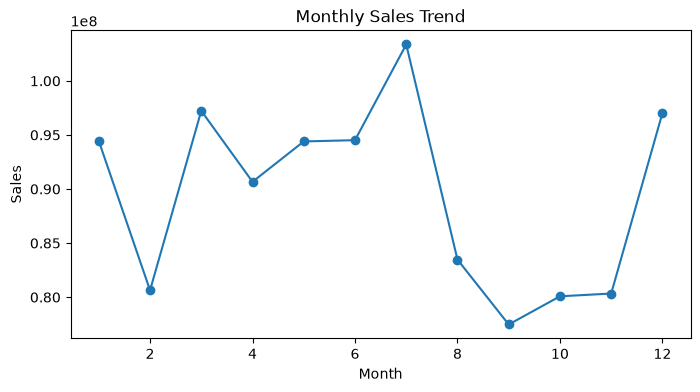

In [16]:
import matplotlib.pyplot as plt

monthly_sales = train.groupby("month")["sales"].sum()

plt.figure(figsize=(8,4))
plt.plot(monthly_sales, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

In [17]:
train["day"] = train["date"].dt.day
train["weekday"] = train["date"].dt.weekday
train["year"] = train["date"].dt.year

train[["date", "year", "month", "day", "weekday"]].head()

,date,year,month,day,weekday
0,2013-01-01,2013,1,1,1
1,2013-01-01,2013,1,1,1
2,2013-01-01,2013,1,1,1
3,2013-01-01,2013,1,1,1
4,2013-01-01,2013,1,1,1


In [18]:
weekday_sales = train.groupby("weekday")["sales"].mean()
weekday_sales

weekday
0    346.544732
1    319.823843
2    332.909401
3    283.540517
4    325.238138
5    433.336472
6    463.085366
Name: sales, dtype: float64

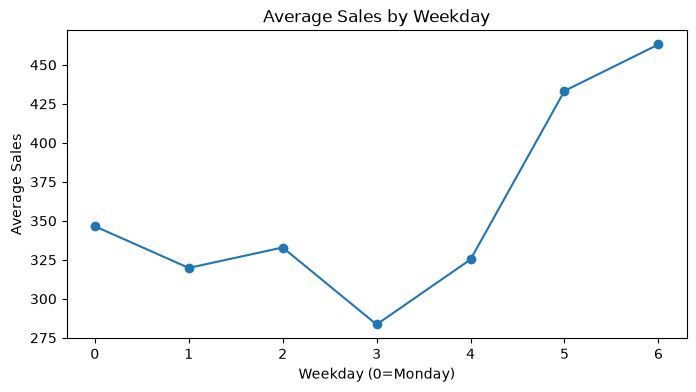

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(weekday_sales, marker="o")
plt.title("Average Sales by Weekday")
plt.xlabel("Weekday (0=Monday)")
plt.ylabel("Average Sales")
plt.show()

In [20]:
top_families = train.groupby("family")["sales"].sum().sort_values(ascending=False).head(10)
top_families

family
GROCERY I        3.434627e+08
BEVERAGES        2.169545e+08
PRODUCE          1.227047e+08
CLEANING         9.752129e+07
DAIRY            6.448771e+07
BREAD/BAKERY     4.213395e+07
POULTRY          3.187600e+07
MEATS            3.108647e+07
PERSONAL CARE    2.459205e+07
DELI             2.411032e+07
Name: sales, dtype: float64

In [22]:
df = train.copy()
df = df[["date", "store_nbr", "family", "sales"]]
df.head()

,date,store_nbr,family,sales
0,2013-01-01,1,AUTOMOTIVE,0.0
1,2013-01-01,1,BABY CARE,0.0
2,2013-01-01,1,BEAUTY,0.0
3,2013-01-01,1,BEVERAGES,0.0
4,2013-01-01,1,BOOKS,0.0


In [23]:
df["date"] = pd.to_datetime(df["date"])

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["weekday"] = df["date"].dt.weekday

In [24]:
store_family_avg = df.groupby(["store_nbr", "family"])["sales"].mean().reset_index()
store_family_avg.head()

,store_nbr,family,sales
0,1,AUTOMOTIVE,3.251188
1,1,BABY CARE,0.000000
2,1,BEAUTY,2.408551
3,1,BEVERAGES,1587.748812
4,1,BOOKS,0.125297


In [25]:
df = train.copy()

df = df[["date", "store_nbr", "family", "sales"]]
df["date"] = pd.to_datetime(df["date"])

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["weekday"] = df["date"].dt.weekday

df.head()

,date,store_nbr,family,sales,year,month,day,weekday
0,2013-01-01,1,AUTOMOTIVE,0.0,2013,1,1,1
1,2013-01-01,1,BABY CARE,0.0,2013,1,1,1
2,2013-01-01,1,BEAUTY,0.0,2013,1,1,1
3,2013-01-01,1,BEVERAGES,0.0,2013,1,1,1
4,2013-01-01,1,BOOKS,0.0,2013,1,1,1


In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["family"] = le.fit_transform(df["family"])

In [27]:
X = df[["store_nbr", "family", "year", "month", "day", "weekday"]]
y = df["sales"]

In [28]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6)
model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [31]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 424.3465150215589


In [32]:
df = df.sort_values(["store_nbr", "family", "date"])

In [33]:
df["lag_1"] = df.groupby(["store_nbr", "family"])["sales"].shift(1)

In [34]:
df["rolling_7"] = df.groupby(["store_nbr", "family"])["sales"].shift(1).rolling(7).mean()

In [35]:
df = df.dropna()

In [36]:
X = df[["store_nbr", "family", "year", "month", "day", "weekday", "lag_1", "rolling_7"]]
y = df["sales"]

In [37]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBRegressor(n_estimators=150, learning_rate=0.1, max_depth=6)
model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [38]:
from sklearn.metrics import mean_squared_error
import numpy as np

pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("Improved RMSE:", rmse)

Improved RMSE: 237.73940492660307


In [39]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, pred)
print("R² Score:", r2)
print("Percentage:", r2 * 100)

R² Score: 0.9529235123391735
Percentage: 95.29235123391734


In [42]:
import joblib

joblib.dump(model, "xgboost_sales_model.pkl")
print("Model saved successfully")

Model saved successfully


In [43]:
X.columns

Index(['store_nbr', 'family', 'year', 'month', 'day', 'weekday', 'lag_1',
       'rolling_7'],
      dtype='str')

In [44]:
train["family"].unique()

<StringArray>
[                'AUTOMOTIVE',                  'BABY CARE',
                     'BEAUTY',                  'BEVERAGES',
                      'BOOKS',               'BREAD/BAKERY',
                'CELEBRATION',                   'CLEANING',
                      'DAIRY',                       'DELI',
                       'EGGS',               'FROZEN FOODS',
                  'GROCERY I',                 'GROCERY II',
                   'HARDWARE',         'HOME AND KITCHEN I',
        'HOME AND KITCHEN II',            'HOME APPLIANCES',
                  'HOME CARE',                 'LADIESWEAR',
            'LAWN AND GARDEN',                   'LINGERIE',
           'LIQUOR,WINE,BEER',                  'MAGAZINES',
                      'MEATS',              'PERSONAL CARE',
               'PET SUPPLIES',    'PLAYERS AND ELECTRONICS',
                    'POULTRY',             'PREPARED FOODS',
                    'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES',
          

In [45]:
print(sorted(train["family"].unique()))

['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS', 'BREAD/BAKERY', 'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI', 'EGGS', 'FROZEN FOODS', 'GROCERY I', 'GROCERY II', 'HARDWARE', 'HOME AND KITCHEN I', 'HOME AND KITCHEN II', 'HOME APPLIANCES', 'HOME CARE', 'LADIESWEAR', 'LAWN AND GARDEN', 'LINGERIE', 'LIQUOR,WINE,BEER', 'MAGAZINES', 'MEATS', 'PERSONAL CARE', 'PET SUPPLIES', 'PLAYERS AND ELECTRONICS', 'POULTRY', 'PREPARED FOODS', 'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES', 'SEAFOOD']


In [46]:
X.columns

Index(['store_nbr', 'family', 'year', 'month', 'day', 'weekday', 'lag_1',
       'rolling_7'],
      dtype='str')

In [47]:
X.head()

,store_nbr,family,year,month,day,weekday,lag_1,rolling_7
12474,1,0,2013,1,8,1,0.0,2.142857
14256,1,0,2013,1,9,2,2.0,2.428571
16038,1,0,2013,1,10,3,2.0,2.428571
17820,1,0,2013,1,11,4,2.0,2.285714
19602,1,0,2013,1,12,5,3.0,2.285714


In [48]:
train[["family"]].drop_duplicates().reset_index(drop=True)

,family
0,AUTOMOTIVE
1,BABY CARE
2,BEAUTY
3,BEVERAGES
4,BOOKS
5,BREAD/BAKERY
6,CELEBRATION
7,CLEANING
8,DAIRY
9,DELI


In [49]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(train["family"])

mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)

{'AUTOMOTIVE': np.int64(0), 'BABY CARE': np.int64(1), 'BEAUTY': np.int64(2), 'BEVERAGES': np.int64(3), 'BOOKS': np.int64(4), 'BREAD/BAKERY': np.int64(5), 'CELEBRATION': np.int64(6), 'CLEANING': np.int64(7), 'DAIRY': np.int64(8), 'DELI': np.int64(9), 'EGGS': np.int64(10), 'FROZEN FOODS': np.int64(11), 'GROCERY I': np.int64(12), 'GROCERY II': np.int64(13), 'HARDWARE': np.int64(14), 'HOME AND KITCHEN I': np.int64(15), 'HOME AND KITCHEN II': np.int64(16), 'HOME APPLIANCES': np.int64(17), 'HOME CARE': np.int64(18), 'LADIESWEAR': np.int64(19), 'LAWN AND GARDEN': np.int64(20), 'LINGERIE': np.int64(21), 'LIQUOR,WINE,BEER': np.int64(22), 'MAGAZINES': np.int64(23), 'MEATS': np.int64(24), 'PERSONAL CARE': np.int64(25), 'PET SUPPLIES': np.int64(26), 'PLAYERS AND ELECTRONICS': np.int64(27), 'POULTRY': np.int64(28), 'PREPARED FOODS': np.int64(29), 'PRODUCE': np.int64(30), 'SCHOOL AND OFFICE SUPPLIES': np.int64(31), 'SEAFOOD': np.int64(32)}
